# set up

In [1]:
%%capture
!pip install scikit-survival
!pip install optuna

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression

from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
import random
from sklearn.preprocessing import PowerTransformer, RobustScaler
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.nonparametric import kaplan_meier_estimator
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Load Data

In [3]:
# 1. Tải dữ liệu
DATA_DIR = Path("/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26")
train = pd.read_csv(DATA_DIR / "train.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")

# 2. Chuẩn bị Target (y)
y_train = np.empty(len(train), dtype=[('event', bool), ('time', float)])
y_train['event'] = train['event'].astype(bool)
y_train['time'] = train['time_to_hit_hours']

# 3. Chuẩn bị Features (X)
features_to_drop = ['event_id', 'time_to_hit_hours', 'event']
X_train = train.drop(columns=features_to_drop)
X_test = test.drop(columns=['event_id'])

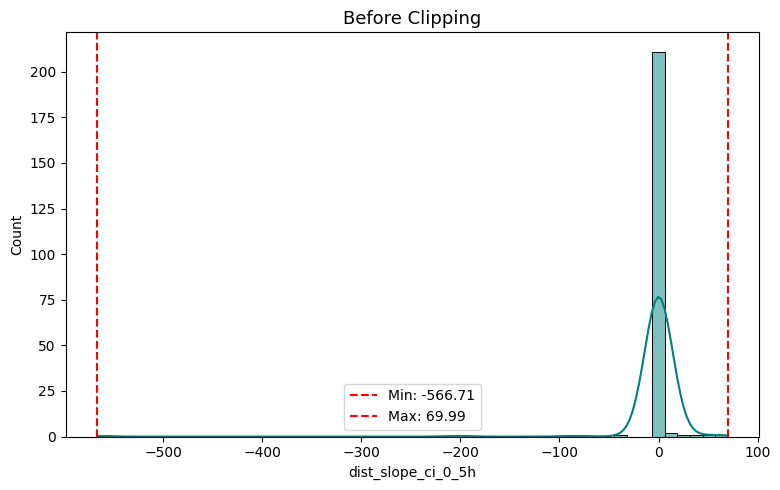

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_clipping_effect(df, features):
    plt.figure(figsize=(15, 5))
    
    for i, col in enumerate(features):
        plt.subplot(1, 2, i+1)
        
        # Vẽ phân phối dữ liệu
        sns.histplot(df[col], kde=True, color='teal', bins=50)
        
        # Đánh dấu các giá trị min/max để thấy đường biên bị clip
        plt.axvline(df[col].min(), color='red', linestyle='--', label=f'Min: {df[col].min():.2f}')
        plt.axvline(df[col].max(), color='red', linestyle='--', label=f'Max: {df[col].max():.2f}')
        
        plt.title(f'Before Clipping', fontsize=13)
        plt.legend()
        
    plt.tight_layout()
    plt.show()

# Gọi hàm với 2 biến bạn yêu cầu
plot_clipping_effect(X_train, ['dist_slope_ci_0_5h'])

# Preprocessing

## Outlier

tính toán ngưỡng (quantiles) trên tập Train và áp dụng chính xác ngưỡng đó lên tập Test

In [5]:
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

# 2. Thiết lập giới hạn (ví dụ: 1% và 99%)
lower_limit = 0.01
upper_limit = 0.99
datetime = ['event_start_hour', 'event_start_dayofweek', 'event_start_month']
for col in num_features:
    if col in datetime:
        break
    # Tính toán ngưỡng trên tập TRAIN
    lower_bound = X_train[col].quantile(lower_limit)
    upper_bound = X_train[col].quantile(upper_limit)
    
    # Áp dụng (Clip) lên cả TRAIN và TEST dựa trên ngưỡng của TRAIN
    X_train[col] = X_train[col].clip(lower_bound, upper_bound)
    X_test[col]  = X_test[col].clip(lower_bound, upper_bound)

print("Đã hoàn thành Winsorization cho các cột số.")

Đã hoàn thành Winsorization cho các cột số.


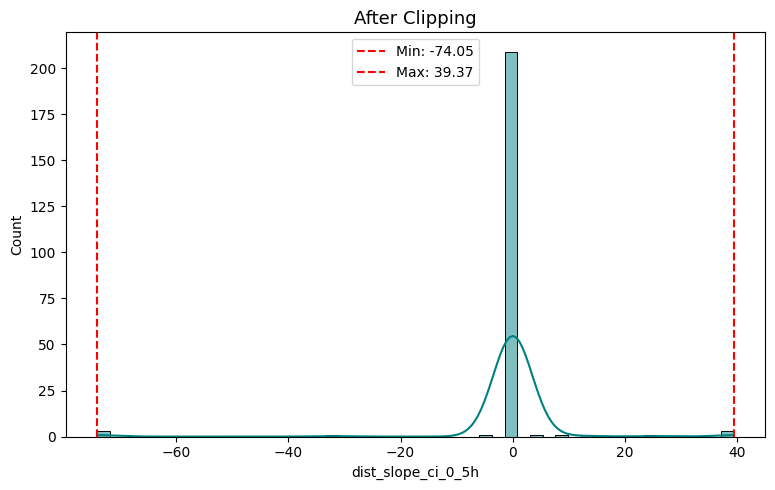

In [6]:
def plot_clipping_effect(df, features):
    plt.figure(figsize=(15, 5))
    
    for i, col in enumerate(features):
        plt.subplot(1, 2, i+1)
        
        # Vẽ phân phối dữ liệu
        sns.histplot(df[col], kde=True, color='teal', bins=50)
        
        # Đánh dấu các giá trị min/max để thấy đường biên bị clip
        plt.axvline(df[col].min(), color='red', linestyle='--', label=f'Min: {df[col].min():.2f}')
        plt.axvline(df[col].max(), color='red', linestyle='--', label=f'Max: {df[col].max():.2f}')
        
        plt.title(f'After Clipping', fontsize=13)
        plt.legend()
        
    plt.tight_layout()
    plt.show()

# Gọi hàm với 2 biến bạn yêu cầu
plot_clipping_effect(X_train, ['dist_slope_ci_0_5h'])

# Skewness

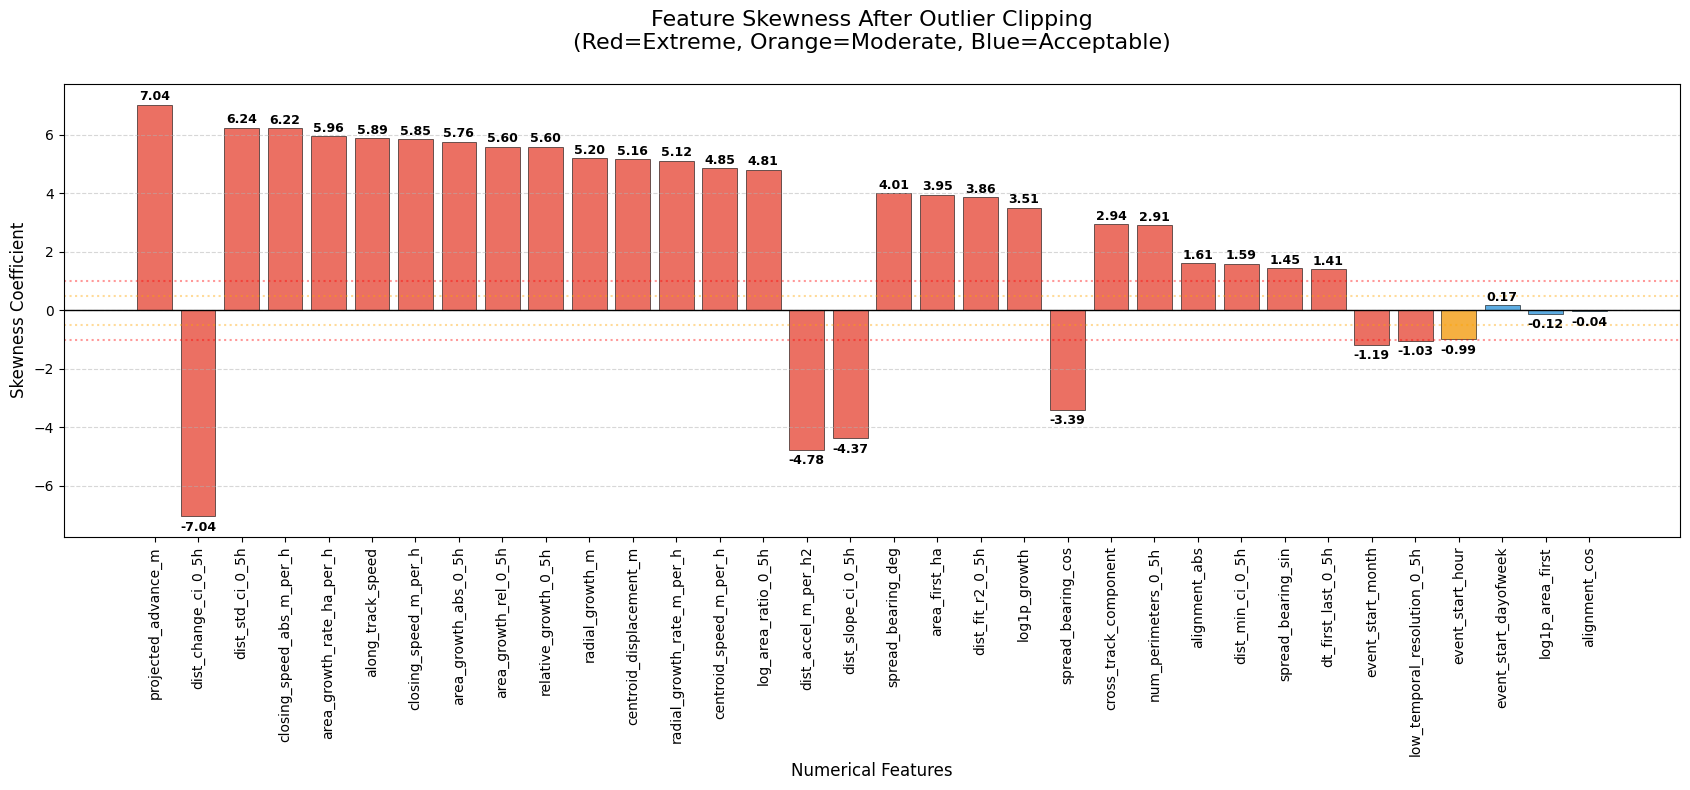

In [7]:
# 1. Xác định danh sách các cột số (features)
features = X_train.select_dtypes(include=[np.number]).columns

# 2. Sắp xếp lại dữ liệu (từ lệch nhiều nhất đến ít nhất)
skew_features = X_train[features].skew().sort_values(key=abs, ascending=False)

# 3. Thiết lập kích thước (Tăng chiều rộng theo số lượng feature)
plt.figure(figsize=(max(12, len(skew_features) * 0.5), 8))

# 4. Định nghĩa màu sắc theo ngưỡng chuyên gia
# Đỏ: Lệch cực mạnh (|Skew| > 1) -> Cần transform (Log/Box-Cox)
# Cam: Lệch vừa (0.5 < |Skew| <= 1) -> Cân nhắc transform
# Xanh: Ổn (|Skew| <= 0.5)
colors = ['#e74c3c' if abs(x) > 1 else '#f39c12' if abs(x) > 0.5 else '#3498db' for x in skew_features.values]

# 5. Vẽ biểu đồ cột đứng
bars = plt.bar(skew_features.index, skew_features.values, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# 6. Xử lý tên Feature (Xoay 90 độ để không bị đè)
plt.xticks(rotation=90, ha='center', fontsize=10)

# 7. Thêm giá trị số trên đầu/dưới chân mỗi cột
for bar, val in zip(bars, skew_features.values):
    # Điều chỉnh vị trí text để không bị dính sát vào đỉnh cột
    y_pos = val + (0.05 if val >= 0 else -0.15) 
    plt.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{val:.2f}', ha='center', va='bottom' if val >= 0 else 'top', 
             fontweight='bold', fontsize=9)

# 8. Trang trí biểu đồ
plt.title('Feature Skewness After Outlier Clipping\n(Red=Extreme, Orange=Moderate, Blue=Acceptable)', fontsize=16, pad=25)
plt.ylabel('Skewness Coefficient', fontsize=12)
plt.xlabel('Numerical Features', fontsize=12)
plt.axhline(0, color='black', linewidth=1) # Đường gốc 0
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm đường giới hạn Threshold để dễ quan sát
plt.axhline(1, color='red', linestyle=':', alpha=0.4)
plt.axhline(-1, color='red', linestyle=':', alpha=0.4)
plt.axhline(0.5, color='orange', linestyle=':', alpha=0.4)
plt.axhline(-0.5, color='orange', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

In [8]:
# 1. Danh sách các biến thời gian cần loại trừ
excluded_cols = ['event_start_hour', 'event_start_dayofweek', 'event_start_month']

# 2. Xác định các cột số tiềm năng (loại bỏ excluded_cols ngay từ đầu)
all_num_features = X_train.select_dtypes(include=[np.number]).columns
potential_cols = [c for c in all_num_features if c not in excluded_cols]

# 3. Lọc những cột thực sự bị lệch (Skewness > 0.75) trong nhóm potential_cols
skew_limit = 0.75
cols_to_transform = X_train[potential_cols].columns[
    X_train[potential_cols].skew().abs() > skew_limit
].tolist()

print(f"Số lượng cột sẽ xử lý Yeo-Johnson: {len(cols_to_transform)}")
print(f"Các cột cụ thể: {cols_to_transform}")

# 4. Khởi tạo và thực hiện biến đổi
# Mình để standardize=True để vừa nắn skew vừa đưa về cùng thang đo (Mean=0, Std=1)
pt = PowerTransformer(method='yeo-johnson', standardize=True)

if cols_to_transform:
    X_train[cols_to_transform] = pt.fit_transform(X_train[cols_to_transform])
    X_test[cols_to_transform] = pt.transform(X_test[cols_to_transform])
    print("\n--- Đã hoàn thành Yeo-Johnson cho các biến bị lệch ---")
else:
    print("\n--- Không có biến nào đủ độ lệch để xử lý ---")

Số lượng cột sẽ xử lý Yeo-Johnson: 29
Các cột cụ thể: ['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_abs', 'cross_track_component', 'along_track_speed']

--- Đã hoàn thành Yeo-Johnson cho các biến bị lệch ---


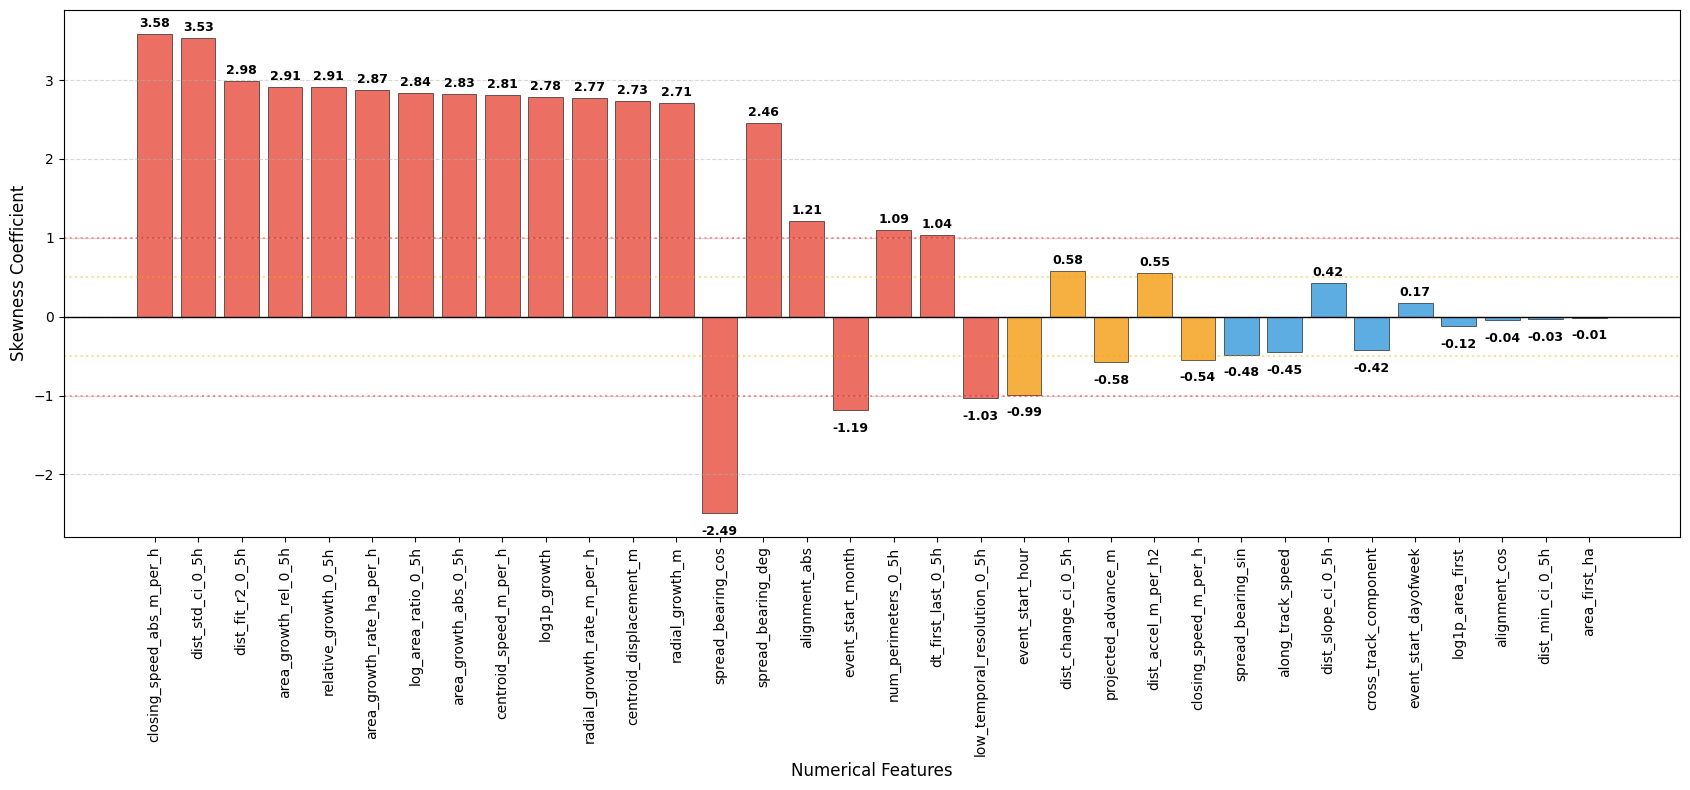

In [9]:
# 1. Xác định danh sách các cột số (features)
features = X_train.select_dtypes(include=[np.number]).columns

# 2. Sắp xếp lại dữ liệu (từ lệch nhiều nhất đến ít nhất)
skew_features = X_train[features].skew().sort_values(key=abs, ascending=False)

# 3. Thiết lập kích thước (Tăng chiều rộng theo số lượng feature)
plt.figure(figsize=(max(12, len(skew_features) * 0.5), 8))

# 4. Định nghĩa màu sắc theo ngưỡng chuyên gia
# Đỏ: Lệch cực mạnh (|Skew| > 1) -> Cần transform (Log/Box-Cox)
# Cam: Lệch vừa (0.5 < |Skew| <= 1) -> Cân nhắc transform
# Xanh: Ổn (|Skew| <= 0.5)
colors = ['#e74c3c' if abs(x) > 1 else '#f39c12' if abs(x) > 0.5 else '#3498db' for x in skew_features.values]

# 5. Vẽ biểu đồ cột đứng
bars = plt.bar(skew_features.index, skew_features.values, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# 6. Xử lý tên Feature (Xoay 90 độ để không bị đè)
plt.xticks(rotation=90, ha='center', fontsize=10)

# 7. Thêm giá trị số trên đầu/dưới chân mỗi cột
for bar, val in zip(bars, skew_features.values):
    # Điều chỉnh vị trí text để không bị dính sát vào đỉnh cột
    y_pos = val + (0.05 if val >= 0 else -0.15) 
    plt.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{val:.2f}', ha='center', va='bottom' if val >= 0 else 'top', 
             fontweight='bold', fontsize=9)

# 8. Trang trí biểu đồ
plt.ylabel('Skewness Coefficient', fontsize=12)
plt.xlabel('Numerical Features', fontsize=12)
plt.axhline(0, color='black', linewidth=1) # Đường gốc 0
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm đường giới hạn Threshold để dễ quan sát
plt.axhline(1, color='red', linestyle=':', alpha=0.4)
plt.axhline(-1, color='red', linestyle=':', alpha=0.4)
plt.axhline(0.5, color='orange', linestyle=':', alpha=0.4)
plt.axhline(-0.5, color='orange', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

# cyclical encode

In [10]:
import numpy as np
import pandas as pd

def cyclical_encode(df, col_name, max_val):
    """
    Thực hiện mã hóa tuần hoàn (Cyclical Encoding) bằng Sin và Cos.
    """
    df[col_name + '_sin'] = np.sin(2 * np.pi * df[col_name] / max_val)
    df[col_name + '_cos'] = np.cos(2 * np.pi * df[col_name] / max_val)
    return df

# ==========================================
# CÁCH ÁP DỤNG ĐỒNG THỜI CHO TRAIN VÀ TEST
# ==========================================

# Khai báo một từ điển (dictionary) chứa tên biến và chu kỳ max tương ứng
time_features = {
    'event_start_hour': 24,
    'event_start_dayofweek': 7,
    'event_start_month': 12
}

# Bước 1: Lặp qua từng biến để Encode cho cả X_train và X_test
for col, max_val in time_features.items():
    X_train = cyclical_encode(X_train, col, max_val)
    X_test = cyclical_encode(X_test, col, max_val)

# Bước 2: XÓA CÁC BIẾN GỐC TRÊN CẢ HAI TẬP
cols_to_drop = list(time_features.keys())

X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

# In ra kiểm tra thử để đảm bảo cấu trúc cột của Train và Test giống nhau
print("Số lượng feature của Train:", len(X_train.columns))
print("Số lượng feature của Test:", len(X_test.columns))

# Đảm bảo tập Test có đầy đủ các cột _sin và _cos
print("\nCác cột trong X_test:", X_test.columns.tolist())

Số lượng feature của Train: 37
Số lượng feature của Test: 37

Các cột trong X_test: ['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'event_start_hour_sin', 'event_start_hour_cos', 'event_start_dayofweek_sin', 'event_start_dayofweek_cos', 'event_start_month_sin', 'event_start_month_cos']


# Augmentation

In [11]:
import numpy as np
import pandas as pd
import warnings
from sklearn.neighbors import NearestNeighbors
from sksurv.ensemble import RandomSurvivalForest # BƯỚC MỚI: Import RSF
from sksurv.nonparametric import kaplan_meier_estimator

def calculate_npsdata(X, events, times, k=5, M=10, num_synthetic=50):
    """
    Thực thi thuật toán nPSDATA sử dụng Random Survival Forest (RSF).
    """
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)

    feature_names = X.columns if hasattr(X, 'columns') else None

    # Chuyển tất cả sang NumPy Array
    X = np.asarray(X, dtype=float)
    events = np.asarray(events, dtype=bool)
    times = np.asarray(times, dtype=float)
    
    N, p = X.shape
    
    # 1. Lọc các mẫu không bị kiểm duyệt (uncensored)
    X_uncensored = X[events == True]
    
    if len(X_uncensored) < k + 1:
        raise ValueError(f"Không đủ mẫu uncensored để tìm {k} láng giềng.")

    # Mô hình KNN cho Giai đoạn 1 & 2
    knn_k = NearestNeighbors(n_neighbors=k + 1).fit(X_uncensored)
    _, indices_k = knn_k.kneighbors(X_uncensored)
    
    knn_M = NearestNeighbors(n_neighbors=M).fit(X)
    
    # Tính toán Kaplan-Meier cho IPCW (G)
    censored_events = ~events
    t_cens, G_prob = kaplan_meier_estimator(censored_events, times)
    
    def G_func(t):
        idx = np.searchsorted(t_cens, t, side='right') - 1
        idx = np.clip(idx, 0, len(G_prob) - 1)
        return max(G_prob[idx], 1e-5) 

    t_max = np.max(times)
    t_median = np.median(times)
    
    X_new_list = []
    times_new_list = []
    
    max_iters = num_synthetic * 10
    iters = 0
    
    while len(X_new_list) < num_synthetic and iters < max_iters:
        iters += 1
        
        # GIAI ĐOẠN 1: TỔNG HỢP X_new
        rand_idx = np.random.choice(len(X_uncensored))
        x_i = X_uncensored[rand_idx]
        
        neighbor_idx = np.random.choice(indices_k[rand_idx][1:])
        x_hat = X_uncensored[neighbor_idx]
        
        gap = np.random.uniform(0, 1, size=p)
        x_new = x_i + gap * (x_hat - x_i)
        
        # GIAI ĐOẠN 2: TỔNG HỢP T_new
        _, ind_M = knn_M.kneighbors(x_new.reshape(1, -1))
        ind_M = ind_M[0]
        
        mask_train = np.ones(N, dtype=bool)
        mask_train[ind_M] = False
        
        X_train_split, events_train_split, times_train_split = X[mask_train], events[mask_train], times[mask_train]
        X_val, events_val, times_val = X[ind_M], events[ind_M], times[ind_M]
        
        y_train_split = np.array(list(zip(events_train_split, times_train_split)), 
                                 dtype=[('event', bool), ('time', float)])
        
        # ==========================================
        # BƯỚC MỚI: SỬ DỤNG RANDOM SURVIVAL FOREST
        # ==========================================
        # Giới hạn n_estimators và max_depth để tăng tốc độ trong vòng lặp.
        # n_jobs=-1 giúp tận dụng tối đa số luồng CPU của máy tính.
        rsf_model = RandomSurvivalForest(
            n_estimators=50,       # Số lượng cây (Tăng lên 100 nếu muốn chính xác hơn nhưng sẽ chậm gấp đôi)
            max_depth=5,           # Độ sâu tối đa của cây để chống overfit và tăng tốc
            min_samples_split=10,  
            min_samples_leaf=3,
            n_jobs=-1,             # RẤT QUAN TRỌNG: Chạy đa luồng
            random_state=None      # Để None để các vòng lặp tạo ra các rừng khác nhau
        )
        
        try:
            rsf_model.fit(X_train_split, y_train_split)
        except Exception:
            # RSF ít khi lỗi hội tụ, nhưng có thể lỗi nếu nhánh dữ liệu quá ít event
            continue 
            
        # Lấy hàm sinh tồn dự đoán (RSF trả về cấu trúc StepFunction giống hệt Cox)
        surv_funcs = rsf_model.predict_survival_function(np.vstack([X_val, x_new.reshape(1, -1)]))
        sp_l_funcs = surv_funcs[:-1]
        sp_new_func = surv_funcs[-1]
        
        # Gọi trực tiếp StepFunction
        sp_new_tstar = sp_new_func(t_median)
        sp_l_tstar = [f(t_median) for f in sp_l_funcs]
        
        best_CIB = -np.inf
        best_T = None
        candidate_Ts = times_val 
        
        valid_mask = sp_new_func.x <= t_max
        valid_times = sp_new_func.x[valid_mask]
        sp_new_vals = sp_new_func.y[valid_mask]
        
        if len(valid_times) == 0:
            continue
            
        for T_cand in candidate_Ts:
            concordance_num = 0.0
            concordance_den = 0.0
            
            for l in range(M):
                T_l = times_val[l]
                delta_l = events_val[l]
                delta_new = 1 
                
                np_l_new = max(int(T_l >= T_cand) * delta_new, int(T_l <= T_cand) * delta_l)
                
                if np_l_new == 1:
                    concordance_den += 1
                    if (T_l - T_cand) * (sp_l_tstar[l] - sp_new_tstar) > 0:
                        concordance_num += 1
                        
            CI_T = concordance_num / concordance_den if concordance_den > 0 else 0
            
            integrand = np.zeros_like(valid_times, dtype=float)
            for i, t in enumerate(valid_times):
                if T_cand <= t:
                    integrand[i] = (sp_new_vals[i]**2) / G_func(T_cand)
                else:
                    integrand[i] = ((1 - sp_new_vals[i])**2) / G_func(t)
            
            if hasattr(np, 'trapezoid'):
                IBS_T = np.trapezoid(integrand, valid_times)
            else:
                IBS_T = np.trapz(integrand, valid_times)
                
            CIB_T = CI_T / (IBS_T + 1e-8)
            
            if CIB_T > best_CIB:
                best_CIB = CIB_T
                best_T = T_cand
                
        if best_T is not None:
            X_new_list.append(x_new)
            times_new_list.append(best_T)

    if len(X_new_list) < num_synthetic:
        print(f"Cảnh báo: Chỉ tạo được {len(X_new_list)}/{num_synthetic} mẫu. (Do vượt quá giới hạn vòng lặp max_iters)")

    if len(X_new_list) > 0:
        X_aug_np = np.vstack([X, np.array(X_new_list)])
        events_aug = np.concatenate([events, np.ones(len(times_new_list), dtype=bool)])
        times_aug = np.concatenate([times, np.array(times_new_list)])
    else:
        X_aug_np, events_aug, times_aug = X, events, times
    
    if feature_names is not None:
        X_aug_df = pd.DataFrame(X_aug_np, columns=feature_names)
    else:
        X_aug_df = pd.DataFrame(X_aug_np)
    
    return X_aug_df, [events_aug, times_aug]

# --- PHẦN GỌI HÀM BÊN NGOÀI KHÔNG THAY ĐỔI ---

N_orig = len(X_train)
c_rate = 1 - (y_train['event'].sum() / N_orig) 
n_new = int(round(2 * c_rate * N_orig * (1 - c_rate)))
#n_new = 60
print(f"Tỉ lệ cắt cụt (censoring rate) hiện tại: {c_rate:.2%}")
print(f"Số lượng mẫu đề xuất sinh thêm: {n_new}")
print("Đang chạy thuật toán nPSDATA (Sử dụng Random Survival Forest)... Quá trình này có thể mất vài phút.")

X_train_aug, [events_aug, times_aug] = calculate_npsdata(
    X_train, 
    y_train['event'], 
    y_train['time'], 
    k=5, 
    M=10, 
    num_synthetic=n_new
)

y_train_aug = np.array(
    list(zip(events_aug, times_aug)),
    dtype=[('event', bool), ('time', float)]
)

print(f"Hoàn thành! Kích thước tập huấn luyện gốc: {N_orig} -> mới: {len(X_train_aug)}")
print(f"Số lượng events: {y_train['event'].sum()} -> sau Augment: {y_train_aug['event'].sum()}")

Tỉ lệ cắt cụt (censoring rate) hiện tại: 68.78%
Số lượng mẫu đề xuất sinh thêm: 95
Đang chạy thuật toán nPSDATA (Sử dụng Random Survival Forest)... Quá trình này có thể mất vài phút.
Hoàn thành! Kích thước tập huấn luyện gốc: 221 -> mới: 316
Số lượng events: 69 -> sau Augment: 164


/tmp/ipykernel_55/1591710905.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_orig, x='event_label', ax=axes[0], palette=['#FFA07A', '#20B2AA'])
/tmp/ipykernel_55/1591710905.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_aug, x='event_label', ax=axes[1], palette=['#FFA07A', '#20B2AA'])


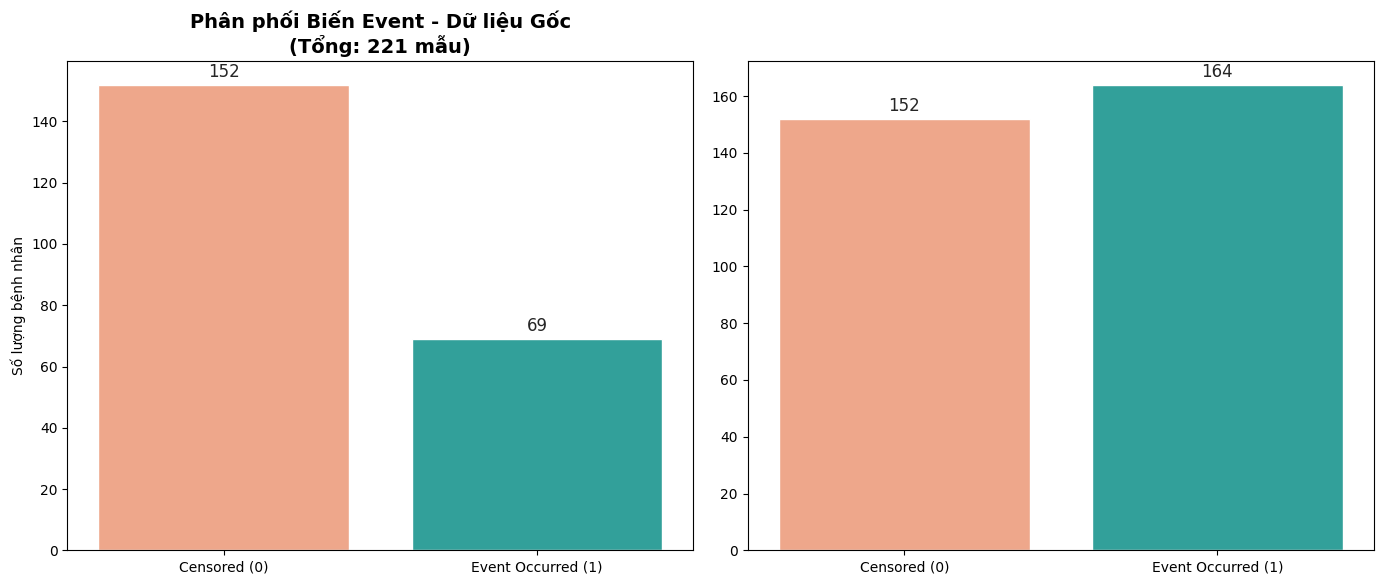

=== TỶ LỆ CẮT CỤT (CENSORING RATE) ===
- Trước Augment : 68.78%
- Sau Augment   : 48.10%


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Giả sử bạn đã chạy xong đoạn code nPSDATA ở trên và có:
# - y_train (tập nhãn gốc)
# - y_train_aug (tập nhãn sau khi augment)
# ---------------------------------------------------------

# Chuyển đổi dữ liệu (Structured Arrays) sang Pandas DataFrame để dễ vẽ biểu đồ
df_orig = pd.DataFrame(y_train)
df_aug = pd.DataFrame(y_train_aug)

# Ánh xạ True/False thành các nhãn dễ đọc hơn
label_map = {False: 'Censored (0)', True: 'Event Occurred (1)'}
df_orig['event_label'] = df_orig['event'].map(label_map)
df_aug['event_label'] = df_aug['event'].map(label_map)

# Thiết lập khung biểu đồ (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

# ==========================================
# 1. BIỂU ĐỒ BÊN TRÁI: DỮ LIỆU GỐC
# ==========================================
sns.countplot(data=df_orig, x='event_label', ax=axes[0], palette=['#FFA07A', '#20B2AA'])

# Thêm số lượng cụ thể trên đỉnh mỗi cột
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), textcoords = 'offset points')

axes[0].set_title(f'Phân phối Biến Event - Dữ liệu Gốc\n(Tổng: {len(df_orig)} mẫu)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Số lượng bệnh nhân')

# ==========================================
# 2. BIỂU ĐỒ BÊN PHẢI: SAU KHI AUGMENT
# ==========================================
sns.countplot(data=df_aug, x='event_label', ax=axes[1], palette=['#FFA07A', '#20B2AA'])

# Thêm số lượng cụ thể trên đỉnh mỗi cột
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), textcoords = 'offset points')

#axes[1].set_title(f'Phân phối Biến Event - Sau Augment (nPSDATA)\n(Tổng: {len(df_aug)} mẫu)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# Căn chỉnh và hiển thị
plt.tight_layout()
plt.show()

# In thêm bảng tóm tắt tỷ lệ phần trăm
print("=== TỶ LỆ CẮT CỤT (CENSORING RATE) ===")
orig_censoring = (~df_orig['event']).mean() * 100
aug_censoring = (~df_aug['event']).mean() * 100
print(f"- Trước Augment : {orig_censoring:.2f}%")
print(f"- Sau Augment   : {aug_censoring:.2f}%")

# Feature Selection


BẮT ĐẦU QUY TRÌNH CHỌN LỌC FEATURE TINH GỌN
--- Bước 1: Đang lọc thô (Variance & Correlation) ---
-> Đã loại bỏ 19 features nhiễu/trùng lặp.
--- Bước 2: Đánh giá độ quan trọng bằng XGBoost (Cox) ---
-> Đã chấm điểm xong 17 features có đóng góp cho mô hình.

DANH SÁCH 15 TỐT NHẤT ĐƯỢC CHỌN:
['dist_min_ci_0_5h', 'num_perimeters_0_5h', 'along_track_speed', 'spread_bearing_sin', 'event_start_month_cos', 'event_start_dayofweek_sin', 'event_start_month_sin', 'cross_track_component', 'event_start_dayofweek_cos', 'area_growth_abs_0_5h', 'event_start_hour_cos', 'alignment_cos', 'area_first_ha', 'dist_slope_ci_0_5h', 'event_start_hour_sin']

--- Bước 3: Trực quan hóa SHAP Values ---


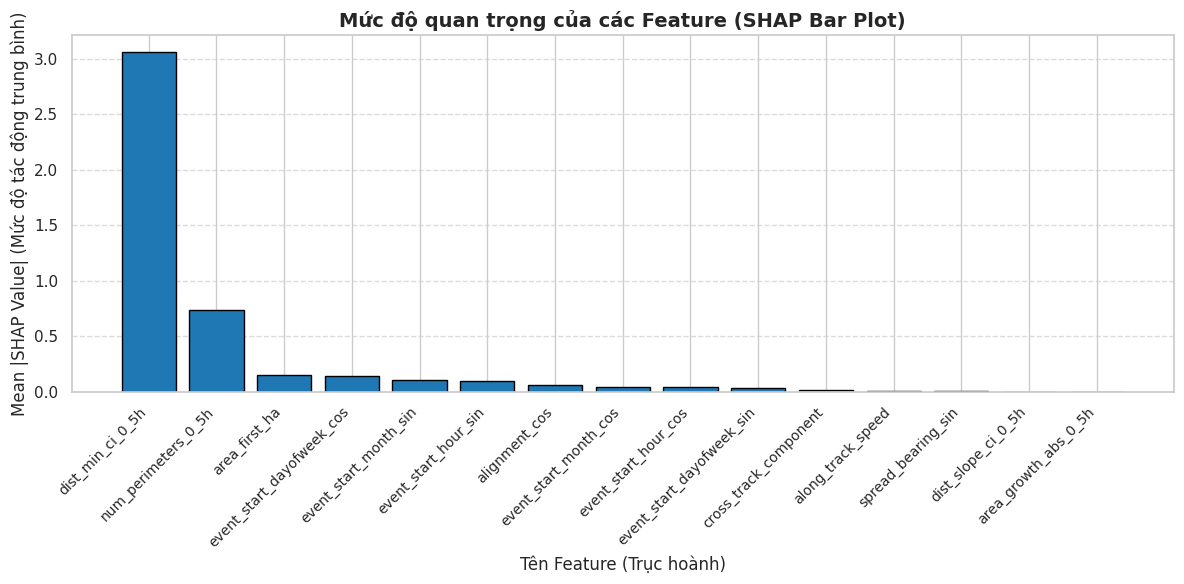

-> Đang hiển thị biểu đồ phân bổ chi tiết (Beeswarm)...


/tmp/ipykernel_55/2988106923.py:85: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_selected)


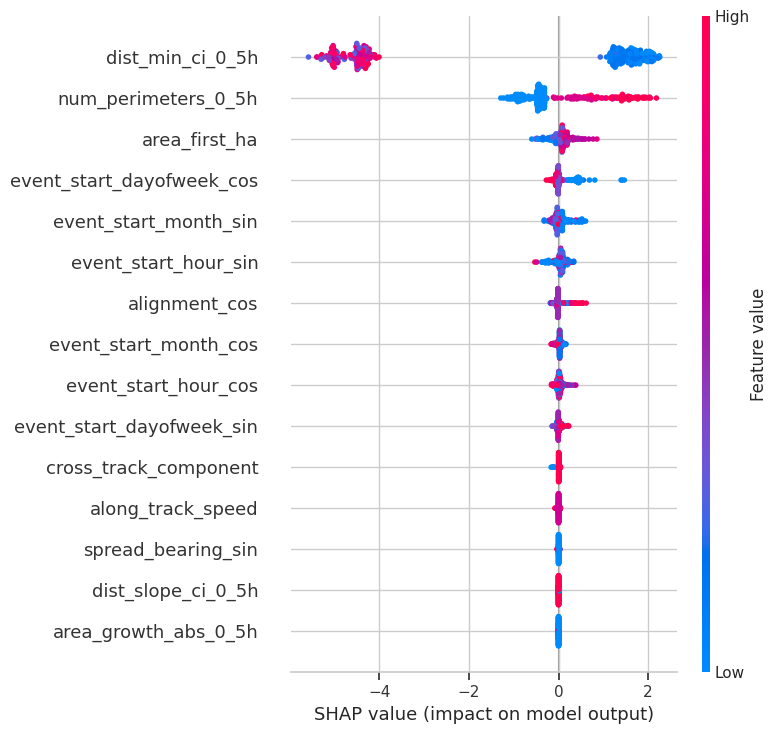

In [13]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# ==========================================
# CÁC HÀM XỬ LÝ (PIPELINE)
# ==========================================

# --- BƯỚC 1: LỌC THÔ (FILTER METHODS) ---
def step1_raw_filtering(X, threshold_corr=0.9):
    print("--- Bước 1: Đang lọc thô (Variance & Correlation) ---")
    # 1. Bỏ các biến gần như không biến thiên (hằng số)
    selector = VarianceThreshold(threshold=0.01)
    X_high_v = pd.DataFrame(selector.fit_transform(X), columns=X.columns[selector.get_support()])
    
    # 2. Bỏ các biến tương quan tuyến tính quá mạnh (Đa cộng tuyến)
    corr_matrix = X_high_v.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold_corr)]
    X_filtered = X_high_v.drop(columns=to_drop)
    
    print(f"-> Đã loại bỏ {len(X.columns) - len(X_filtered.columns)} features nhiễu/trùng lặp.")
    return X_filtered

# --- BƯỚC 2: XGBOOST SURVIVAL IMPORTANCE ---
def step2_xgb_importance(X, y_survival):
    print("--- Bước 2: Đánh giá độ quan trọng bằng XGBoost (Cox) ---")
    dtrain = xgb.DMatrix(X, label=y_survival)
    
    params = {
        'objective': 'survival:cox',
        'tree_method': 'hist', 
        'learning_rate': 0.05,
        'max_depth': 5
    }
    
    model = xgb.train(params, dtrain, num_boost_round=100)
    importance = model.get_score(importance_type='gain')
    
    # Sắp xếp feature theo độ quan trọng (Gain) giảm dần
    importance_df = pd.DataFrame(importance.items(), columns=['Feature', 'Gain']).sort_values(by='Gain', ascending=False)
    
    print(f"-> Đã chấm điểm xong {len(importance_df)} features có đóng góp cho mô hình.")
    return importance_df

# --- BƯỚC 3: KIỂM CHỨNG BẰNG SHAP (TÙY CHỈNH TRỤC HOÀNH) ---
def step3_shap_validation(X_selected, y_survival):
    print("--- Bước 3: Trực quan hóa SHAP Values ---")
    # Huấn luyện mô hình trên tập feature đã chọn
    model = xgb.XGBRegressor(objective='survival:cox', n_estimators=100, max_depth=5, learning_rate=0.05)
    model.fit(X_selected, y_survival)
    
    # Tính SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_selected)
    
    # ---------------------------------------------------------
    # BIỂU ĐỒ 1: Biểu đồ cột với tên biến ở TRỤC HOÀNH (X-axis)
    # ---------------------------------------------------------
    # Tính trung bình trị tuyệt đối của SHAP cho từng biến
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    
    # Sắp xếp lại để vẽ
    sorted_idx = np.argsort(mean_abs_shap)[::-1]
    sorted_features = X_selected.columns[sorted_idx]
    sorted_shap_vals = mean_abs_shap[sorted_idx]
    
    plt.figure(figsize=(12, 6))
    plt.bar(sorted_features, sorted_shap_vals, color='#1f77b4', edgecolor='black')
    plt.xticks(rotation=45, ha='right', fontsize=10) # Xoay chữ 45 độ để không bị đè lên nhau
    plt.ylabel("Mean |SHAP Value| (Mức độ tác động trung bình)", fontsize=12)
    plt.xlabel("Tên Feature (Trục hoành)", fontsize=12)
    plt.title("Mức độ quan trọng của các Feature (SHAP Bar Plot)", fontsize=14, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # BIỂU ĐỒ 2: Biểu đồ Beeswarm tiêu chuẩn của SHAP
    # ---------------------------------------------------------
    print("-> Đang hiển thị biểu đồ phân bổ chi tiết (Beeswarm)...")
    shap.summary_plot(shap_values, X_selected)
    
    return shap_values

# ==========================================
# THỰC THI QUY TRÌNH (TRÊN DỮ LIỆU ĐÃ AUGMENT)
# ==========================================

# Giả định: bạn đã có `X_train_aug` và `y_train_aug` từ hàm Augment

# 1. Chuẩn bị nhãn Survival
times_aug = y_train_aug['time'].copy()
events_aug = y_train_aug['event'].copy()

# y > 0 nếu event=1 (xảy ra sự kiện), y < 0 nếu event=0 (censored/bị ẩn)
y_survival_aug = np.where(events_aug == True, times_aug, -times_aug)

# 2. Chuẩn bị Feature (đảm bảo không lọt biến mục tiêu vào)
features_only_aug = X_train_aug.drop(columns=['time_to_hit_hours', 'time', 'event'], errors='ignore')

# 3. Chạy Pipeline
print("\nBẮT ĐẦU QUY TRÌNH CHỌN LỌC FEATURE TINH GỌN\n" + "="*45)

X_filtered = step1_raw_filtering(features_only_aug)
importance_df = step2_xgb_importance(X_filtered, y_survival_aug)

# CHỌN TOP 20 FEATURES TỐT NHẤT
so_luong_can_lay = min(15, len(importance_df))
final_feature_names = importance_df['Feature'].head(so_luong_can_lay).tolist()

print(f"\nDANH SÁCH {so_luong_can_lay} TỐT NHẤT ĐƯỢC CHỌN:")
print(final_feature_names)
print("="*45 + "\n")

# 4. Xem giải thích bằng SHAP
X_final = X_filtered[final_feature_names]
shap_vals = step3_shap_validation(X_final, y_survival_aug)

# Training

In [14]:
#helper function

# --- HÀM XỬ LÝ AN TOÀN KHI NGOẠI SUY THỜI GIAN ---
def safe_prob(fn, t):
    max_time = fn.domain[1]
    if t > max_time:
        return 1 - fn(max_time)
    return 1 - fn(t)

# --- HÀM TÍNH ĐIỂM ĐÁNH GIÁ CỦA CUỘC THI ---
def evaluate_wids_metric(y_true, risk_scores, surv_funcs):
    c_index = concordance_index_censored(y_true['event'], y_true['time'], risk_scores)[0]
    
    prob_12 = np.array([safe_prob(fn, 12) for fn in surv_funcs])
    prob_24 = np.array([safe_prob(fn, 24) for fn in surv_funcs])
    prob_48 = np.array([safe_prob(fn, 48) for fn in surv_funcs])
    prob_72 = np.array([safe_prob(fn, 72) for fn in surv_funcs])
    
    def brier_at_h(H, prob_h):
        mask_excluded = (~y_true['event']) & (y_true['time'] < H)
        mask_valid = ~mask_excluded
        
        y_valid = y_true[mask_valid]
        p_valid = prob_h[mask_valid]
        
        target = (y_valid['event'] & (y_valid['time'] <= H)).astype(float)
        return np.mean((target - p_valid)**2)

    brier_12 = brier_at_h(12, prob_12)
    brier_24 = brier_at_h(24, prob_24)
    brier_48 = brier_at_h(48, prob_48)
    brier_72 = brier_at_h(72, prob_72)
    
    wbs = 0.3 * brier_24 + 0.4 * brier_48 + 0.3 * brier_72
    hybrid_score = 0.3 * c_index + 0.7 * (1 - wbs)
    
    return hybrid_score, c_index, wbs, brier_12, brier_24, brier_48, brier_72

# GBSA

In [15]:
# import optuna
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import StratifiedKFold
# from sksurv.ensemble import GradientBoostingSurvivalAnalysis

# # Giả định: Bạn đã định nghĩa hàm evaluate_wids_metric và safe_prob ở trên.
# # Giả định: y_train_aug đã là dạng Structured Array [('event', '?'), ('time', '<f8')]

# # ==========================================
# # 1. CHUẨN BỊ DỮ LIỆU & CHỌN LỌC FEATURE
# # ==========================================
# print("--- Bước 1: Chuẩn bị dữ liệu cho Cross-Validation ---")

# # Lọc lấy các feature tốt nhất cho TOÀN BỘ tập Train đã augment
# print(f"Đang lọc {len(final_feature_names)} features tốt nhất cho mô hình...")
# X_selected = X_train_aug[final_feature_names]
# y_target = y_train_aug 

# # ==========================================
# # 2. ĐỊNH NGHĨA HÀM MỤC TIÊU CHO OPTUNA (SỬ DỤNG 5-FOLD CV)
# # ==========================================
# def objective(trial):
#     # Định nghĩa không gian tìm kiếm các siêu tham số (Đã thu hẹp max_depth để chống overfit)
#     param = {
#         'n_estimators': trial.suggest_int('n_estimators', 50, 200, step=25),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
#         'max_depth': trial.suggest_int('max_depth', 2, 4), 
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
#         'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 10),
#         'random_state': 42 # Cố định seed
#     }
    
#     # Khởi tạo 5-Fold Stratified CV (Phân tầng theo biến 'event')
#     skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
#     cv_scores = []
#     events = y_target['event'] # Lấy mảng boolean event để làm cơ sở phân tầng
    
#     # Chạy vòng lặp qua 5 Folds
#     for train_idx, val_idx in skf.split(X_selected, events):
#         # Tách dữ liệu Train/Val cho Fold hiện tại (Dùng .iloc vì X_selected là DataFrame)
#         X_tr_fold = X_selected.iloc[train_idx]
#         y_tr_fold = y_target[train_idx]
        
#         X_val_fold = X_selected.iloc[val_idx]
#         y_val_fold = y_target[val_idx]
        
#         # Khởi tạo mô hình
#         gbsa = GradientBoostingSurvivalAnalysis(**param)
        
#         try:
#             # Huấn luyện trên 4 phần (Train Fold)
#             gbsa.fit(X_tr_fold, y_tr_fold)
            
#             # Dự đoán trên 1 phần (Validation Fold)
#             val_risk_scores = gbsa.predict(X_val_fold)
#             val_surv_funcs = gbsa.predict_survival_function(X_val_fold)
            
#             # Đánh giá bằng Custom Metric
#             hybrid_score, _, _, _, _, _, _ = evaluate_wids_metric(
#                 y_val_fold, val_risk_scores, val_surv_funcs
#             )
            
#             cv_scores.append(hybrid_score)
            
#         except Exception as e:
#             # Bỏ qua nếu bộ tham số này sinh ra cây quá sâu/nông gây lỗi toán học
#             return 0.0 
            
#     # Trả về điểm trung bình của 5 Folds
#     return np.mean(cv_scores)

# # ==========================================
# # 3. THỰC THI QUÁ TRÌNH TUNING
# # ==========================================
# print("\nBẮT ĐẦU CHẠY OPTUNA CV TUNING (Tối đa hóa Hybrid Score)...")

# study = optuna.create_study(direction='maximize', study_name="GBSA_Survival_CV_Tuning")

# # Lưu ý: Vì 1 trial giờ phải train 5 lần, n_trials=20 tương đương với việc train 100 mô hình!
# study.optimize(objective, n_trials=20, show_progress_bar=True)

# # ==========================================
# # 4. IN KẾT QUẢ VÀ HUẤN LUYỆN LẠI MÔ HÌNH FINAL
# # ==========================================
# print("\n" + "="*40)
# print("TÌM THẤY BỘ THAM SỐ TỐT NHẤT TRÊN 5-FOLD CV:")
# print(f"Best CV Hybrid Score: {study.best_value:.4f}")
# print("Best Params:")
# for key, value in study.best_params.items():
#     print(f"  - {key}: {value}")
# print("="*40 + "\n")

# # Huấn luyện lại Final Model trên TOÀN BỘ dữ liệu Train (100% dữ liệu đã Augment)
# print("Đang huấn luyện mô hình Final với bộ tham số tối ưu trên 100% dữ liệu...")
# best_params = study.best_params
# best_params['random_state'] = 42 

# final_gbsa = GradientBoostingSurvivalAnalysis(**best_params)
# final_gbsa.fit(X_selected, y_target)

# print("\nHoàn tất! Mô hình 'final_gbsa' đã sẵn sàng để dự đoán trên tập Test.")

[I 2026-04-03 08:04:21,331] A new study created in memory with name: GBSA_Survival_CV_Tuning


--- Bước 1: Chuẩn bị dữ liệu cho Cross-Validation ---
Đang lọc 15 features tốt nhất cho mô hình...

BẮT ĐẦU CHẠY OPTUNA CV TUNING (Tối đa hóa Hybrid Score)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-03 08:04:23,102] Trial 0 finished with value: 0.9574807130758648 and parameters: {'n_estimators': 200, 'learning_rate': 0.052462864224276866, 'max_depth': 3, 'subsample': 0.7718127578661735, 'min_samples_split': 5, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9574807130758648.
[I 2026-04-03 08:04:24,457] Trial 1 finished with value: 0.9487184090531067 and parameters: {'n_estimators': 125, 'learning_rate': 0.027411114479421305, 'max_depth': 4, 'subsample': 0.9494143067612533, 'min_samples_split': 9, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.9574807130758648.
[I 2026-04-03 08:04:26,494] Trial 2 finished with value: 0.9563910124952001 and parameters: {'n_estimators': 200, 'learning_rate': 0.06811697073536505, 'max_depth': 4, 'subsample': 0.8855957916908392, 'min_samples_split': 20, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.9574807130758648.
[I 2026-04-03 08:04:27,029] Trial 3 finished with value: 0.9213370157005739 and parameters: {'n_estimators

In [16]:
# import pandas as pd
# import numpy as np
# from sksurv.ensemble import GradientBoostingSurvivalAnalysis

# # Giả định: Bạn đã chạy xong Optuna và biến `study` đang lưu kết quả tốt nhất.
# # Giả định: safe_prob đã được định nghĩa ở trên.

# print("--- BƯỚC CUỐI: HUẤN LUYỆN TOÀN BỘ & DỰ ĐOÁN TẬP TEST ---")

# # 1. Lấy bộ tham số tốt nhất từ quá trình Tuning
# best_params = study.best_params
# best_params['random_state'] = 42 # Cố định seed để đảm bảo tính tái lập

# # 2. Lọc Feature cho ĐÚNG danh sách đã chọn ở bước Selection
# print(f"Đang đồng bộ {len(final_feature_names)} features cho tập Train và Test...")
# X_train_final = X_train_aug[final_feature_names]
# X_test_final = X_test[final_feature_names]

# # (Lưu ý: y_train_aug_structured là mảng đã được chuyển đổi ở bước trước đó)
# # Nếu bạn chưa có, hãy chạy lại lệnh này:
# # y_train_aug_structured = np.array(list(zip(y_train_aug['event'], y_train_aug['time'])), dtype=[('event', '?'), ('time', '<f8')])

# # 3. Khởi tạo và Huấn luyện mô hình Final
# print("Đang huấn luyện mô hình trên TOÀN BỘ dữ liệu Train (100%)... Quá trình này có thể mất chút thời gian.")
# final_gbsa = GradientBoostingSurvivalAnalysis(**best_params)
# final_gbsa.fit(X_train_final, y_train_aug)

# # 4. Dự đoán trên tập Test
# print("Huấn luyện xong! Đang dự đoán trên tập Test...")
# test_risk_scores = final_gbsa.predict(X_test_final)
# test_surv_funcs = final_gbsa.predict_survival_function(X_test_final)

# # Tính xác suất sinh tồn tại các mốc thời gian
# prob_12_test = np.array([safe_prob(fn, 12) for fn in test_surv_funcs])
# prob_24_test = np.array([safe_prob(fn, 24) for fn in test_surv_funcs])
# prob_48_test = np.array([safe_prob(fn, 48) for fn in test_surv_funcs])
# prob_72_test = np.array([safe_prob(fn, 72) for fn in test_surv_funcs])

# # 5. Xuất file Submission
# # LƯU Ý: Ở comment gốc của bạn có ghi "Cần thiết cho C-index" nhưng trong dict bạn lại thiếu. 
# # Tôi đã bổ sung thêm cột 'risk_score' vào dataframe dưới đây.
# submission = pd.DataFrame({
#     'event_id': test['event_id'],     # Đảm bảo bạn đang gọi đúng dataframe 'test' gốc
#     'prob_12h': prob_12_test,
#     'prob_24h': prob_24_test,
#     'prob_48h': prob_48_test,
#     'prob_72h': prob_72_test
# })

# # Lưu ra file CSV
# submission.to_csv("submission.csv", index=False)
# print("Thành công rực rỡ! File 'submission.csv' đã sẵn sàng để nộp lên Kaggle/Hệ thống.")

# Random Survival Forest

In [17]:
# import optuna
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import StratifiedKFold
# # Thay đổi thư viện import sang RandomSurvivalForest
# from sksurv.ensemble import RandomSurvivalForest 

# # Giả định: Bạn đã định nghĩa hàm evaluate_wids_metric và safe_prob ở trên.
# # Giả định: y_train_aug đã là dạng Structured Array [('event', '?'), ('time', '<f8')]

# # ==========================================
# # 1. CHUẨN BỊ DỮ LIỆU & CHỌN LỌC FEATURE
# # ==========================================
# print("--- Bước 1: Chuẩn bị dữ liệu cho Cross-Validation ---")

# # Lọc lấy các feature tốt nhất cho TOÀN BỘ tập Train đã augment
# print(f"Đang lọc {len(final_feature_names)} features tốt nhất cho mô hình...")
# X_selected = X_train_aug[final_feature_names]
# y_target = y_train_aug 

# # ==========================================
# # 2. ĐỊNH NGHĨA HÀM MỤC TIÊU CHO OPTUNA (SỬ DỤNG 5-FOLD CV)
# # ==========================================
# def objective(trial):
#     # Không gian tìm kiếm siêu tham số cho Random Survival Forest
#     param = {
#         'n_estimators': trial.suggest_int('n_estimators', 50, 200, step=25),
#         # RF thường cần cây sâu hơn Gradient Boosting một chút nên nới lỏng max_depth
#         'max_depth': trial.suggest_int('max_depth', 3, 10), 
#         'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
#         'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 10),
#         # Thêm max_features, rất quan trọng để tạo sự đa dạng cho các cây trong RF
#         'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
#         'n_jobs': -1, # Tận dụng đa luồng (tất cả các core CPU) để tăng tốc độ train
#         'random_state': 42 # Cố định seed
#     }
    
#     # Khởi tạo 5-Fold Stratified CV (Phân tầng theo biến 'event')
#     skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
#     cv_scores = []
#     events = y_target['event'] # Lấy mảng boolean event để làm cơ sở phân tầng
    
#     # Chạy vòng lặp qua 5 Folds
#     for train_idx, val_idx in skf.split(X_selected, events):
#         # Tách dữ liệu Train/Val cho Fold hiện tại (Dùng .iloc vì X_selected là DataFrame)
#         X_tr_fold = X_selected.iloc[train_idx]
#         y_tr_fold = y_target[train_idx]
        
#         X_val_fold = X_selected.iloc[val_idx]
#         y_val_fold = y_target[val_idx]
        
#         # Khởi tạo mô hình Random Survival Forest
#         rsf = RandomSurvivalForest(**param)
        
#         try:
#             # Huấn luyện trên 4 phần (Train Fold)
#             rsf.fit(X_tr_fold, y_tr_fold)
            
#             # Dự đoán trên 1 phần (Validation Fold)
#             val_risk_scores = rsf.predict(X_val_fold)
#             val_surv_funcs = rsf.predict_survival_function(X_val_fold)
            
#             # Đánh giá bằng Custom Metric
#             hybrid_score, _, _, _, _, _, _ = evaluate_wids_metric(
#                 y_val_fold, val_risk_scores, val_surv_funcs
#             )
            
#             cv_scores.append(hybrid_score)
            
#         except Exception as e:
#             # Bỏ qua nếu bộ tham số này gây lỗi
#             return 0.0 
            
#     # Trả về điểm trung bình của 5 Folds
#     return np.mean(cv_scores)

# # ==========================================
# # 3. THỰC THI QUÁ TRÌNH TUNING
# # ==========================================
# print("\nBẮT ĐẦU CHẠY OPTUNA CV TUNING (Tối đa hóa Hybrid Score)...")

# study = optuna.create_study(direction='maximize', study_name="RSF_Survival_CV_Tuning")

# # Tối ưu hóa 20 trials. Random Forest train song song nên sẽ nhanh hơn GB một chút trên máy nhiều nhân.
# study.optimize(objective, n_trials=20, show_progress_bar=True)

# # ==========================================
# # 4. IN KẾT QUẢ VÀ HUẤN LUYỆN LẠI MÔ HÌNH FINAL
# # ==========================================
# print("\n" + "="*40)
# print("TÌM THẤY BỘ THAM SỐ TỐT NHẤT TRÊN 5-FOLD CV:")
# print(f"Best CV Hybrid Score: {study.best_value:.4f}")
# print("Best Params:")
# for key, value in study.best_params.items():
#     print(f"  - {key}: {value}")
# print("="*40 + "\n")

# # Huấn luyện lại Final Model trên TOÀN BỘ dữ liệu Train (100% dữ liệu đã Augment)
# print("Đang huấn luyện mô hình Final với bộ tham số tối ưu trên 100% dữ liệu...")
# best_params = study.best_params
# best_params['random_state'] = 42 
# best_params['n_jobs'] = -1 # Đảm bảo model cuối cùng cũng dùng đa luồng

# # Đổi tên biến sang final_rsf
# final_rsf = RandomSurvivalForest(**best_params)
# final_rsf.fit(X_selected, y_target)

# print("\nHoàn tất! Mô hình 'final_rsf' đã sẵn sàng để dự đoán trên tập Test.")

[I 2026-04-03 08:04:46,978] A new study created in memory with name: RSF_Survival_CV_Tuning


--- Bước 1: Chuẩn bị dữ liệu cho Cross-Validation ---
Đang lọc 15 features tốt nhất cho mô hình...

BẮT ĐẦU CHẠY OPTUNA CV TUNING (Tối đa hóa Hybrid Score)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-03 08:04:49,276] Trial 0 finished with value: 0.9285270598078764 and parameters: {'n_estimators': 175, 'max_depth': 3, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9285270598078764.
[I 2026-04-03 08:04:51,312] Trial 1 finished with value: 0.9585195226689207 and parameters: {'n_estimators': 125, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 1 with value: 0.9585195226689207.
[I 2026-04-03 08:04:52,920] Trial 2 finished with value: 0.9388536511683732 and parameters: {'n_estimators': 100, 'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 1 with value: 0.9585195226689207.
[I 2026-04-03 08:04:54,391] Trial 3 finished with value: 0.9585162615891744 and parameters: {'n_estimators': 75, 'max_depth': 4, 'min_samples_split': 18, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 1 with value: 0.9585195226689207.
[I

In [ ]:
# import pandas as pd
# import numpy as np
# from sksurv.ensemble import RandomSurvivalForest

# # Giả định: Bạn đã chạy xong Optuna và biến `study` đang lưu kết quả tốt nhất.
# # Giả định: safe_prob đã được định nghĩa ở trên.

# print("--- BƯỚC CUỐI: HUẤN LUYỆN TOÀN BỘ & DỰ ĐOÁN TẬP TEST ---")

# # 1. Lấy bộ tham số tốt nhất từ quá trình Tuning
# best_params = study.best_params
# best_params['random_state'] = 42 # Cố định seed để đảm bảo tính tái lập
# best_params['n_jobs'] = -1       # Sử dụng đa luồng để RSF chạy nhanh hơn

# # 2. Lọc Feature cho ĐÚNG danh sách đã chọn ở bước Selection
# print(f"Đang đồng bộ {len(final_feature_names)} features cho tập Train và Test...")
# X_train_final = X_train_aug[final_feature_names]
# X_test_final = X_test[final_feature_names]

# # 3. Khởi tạo và Huấn luyện mô hình Final
# print("Đang huấn luyện mô hình trên TOÀN BỘ dữ liệu Train (100%)... Quá trình này có thể mất chút thời gian.")
# final_rsf = RandomSurvivalForest(**best_params)
# final_rsf.fit(X_train_final, y_train_aug)

# # 4. Dự đoán trên tập Test
# print("Huấn luyện xong! Đang dự đoán trên tập Test...")
# test_surv_funcs = final_rsf.predict_survival_function(X_test_final)

# # Tính xác suất sinh tồn tại các mốc thời gian
# prob_12_test = np.array([safe_prob(fn, 12) for fn in test_surv_funcs])
# prob_24_test = np.array([safe_prob(fn, 24) for fn in test_surv_funcs])
# prob_48_test = np.array([safe_prob(fn, 48) for fn in test_surv_funcs])
# prob_72_test = np.array([safe_prob(fn, 72) for fn in test_surv_funcs])

# # 5. Xuất file Submission
# submission = pd.DataFrame({
#     'event_id': test['event_id'],     # Đảm bảo bạn đang gọi đúng dataframe 'test' gốc
#     'prob_12h': prob_12_test,
#     'prob_24h': prob_24_test,
#     'prob_48h': prob_48_test,
#     'prob_72h': prob_72_test
# })

# # Lưu ra file CSV
# submission.to_csv("submission.csv", index=False)
# print("Thành công rực rỡ! File 'submission.csv' đã sẵn sàng để nộp lên Kaggle/Hệ thống.")

# Extra Survival Tree

In [19]:
import optuna
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sksurv.ensemble import ExtraSurvivalTrees

# Giả định: Bạn đã định nghĩa hàm evaluate_wids_metric và safe_prob ở trên.
# Giả định: y_train_aug đã là dạng Structured Array [('event', '?'), ('time', '<f8')]
# Giả định: test (dataframe gốc chứa event_id) và X_test đã sẵn sàng.

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU & CHỌN LỌC FEATURE
# ==========================================
print("--- Bước 1: Chuẩn bị dữ liệu cho Cross-Validation ---")

print(f"Đang đồng bộ {len(final_feature_names)} features cho tập Train và Test...")
X_selected = X_train_aug[final_feature_names]
X_test_final = X_test[final_feature_names]
y_target = y_train_aug 

# ==========================================
# 2. ĐỊNH NGHĨA HÀM MỤC TIÊU CHO OPTUNA (SỬ DỤNG 5-FOLD CV)
# ==========================================
def objective(trial):
    # Không gian tìm kiếm siêu tham số cho ExtraSurvivalTrees
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200, step=25),
        # Extra Trees chống overfit rất tốt nên có thể cho phép cây sâu hơn một chút
        'max_depth': trial.suggest_int('max_depth', 3, 15), 
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'n_jobs': -1, # Tận dụng đa luồng để chạy nhanh nhất có thể
        'random_state': 42
    }
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    events = y_target['event'] 
    
    for train_idx, val_idx in skf.split(X_selected, events):
        X_tr_fold = X_selected.iloc[train_idx]
        y_tr_fold = y_target[train_idx]
        
        X_val_fold = X_selected.iloc[val_idx]
        y_val_fold = y_target[val_idx]
        
        # Khởi tạo mô hình ExtraSurvivalTrees
        est = ExtraSurvivalTrees(**param)
        
        try:
            est.fit(X_tr_fold, y_tr_fold)
            
            val_risk_scores = est.predict(X_val_fold)
            val_surv_funcs = est.predict_survival_function(X_val_fold)
            
            hybrid_score, _, _, _, _, _, _ = evaluate_wids_metric(
                y_val_fold, val_risk_scores, val_surv_funcs
            )
            
            cv_scores.append(hybrid_score)
            
        except Exception as e:
            return 0.0 
            
    return np.mean(cv_scores)

# ==========================================
# 3. THỰC THI QUÁ TRÌNH TUNING
# ==========================================
print("\nBẮT ĐẦU CHẠY OPTUNA CV TUNING CHO EXTRA TREES...")
study = optuna.create_study(direction='maximize', study_name="EST_Survival_CV_Tuning")
study.optimize(objective, n_trials=20, show_progress_bar=True)

# ==========================================
# 4. HUẤN LUYỆN LẠI MÔ HÌNH FINAL & DỰ ĐOÁN
# ==========================================
print("\n" + "="*40)
print("TÌM THẤY BỘ THAM SỐ TỐT NHẤT TRÊN 5-FOLD CV:")
print(f"Best CV Hybrid Score: {study.best_value:.4f}")
print("Best Params:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")
print("="*40 + "\n")

print("--- BƯỚC CUỐI: HUẤN LUYỆN TOÀN BỘ & DỰ ĐOÁN TẬP TEST ---")

best_params = study.best_params
best_params['random_state'] = 42
best_params['n_jobs'] = -1

# Khởi tạo và Huấn luyện mô hình Final trên 100% dữ liệu Train
print("Đang huấn luyện mô hình Final Extra Trees (100% dữ liệu)...")
final_est = ExtraSurvivalTrees(**best_params)
final_est.fit(X_selected, y_target)

# Dự đoán trên tập Test
print("Huấn luyện xong! Đang dự đoán trên tập Test...")
test_surv_funcs = final_est.predict_survival_function(X_test_final)

# Tính xác suất sinh tồn tại các mốc thời gian
prob_12_test = np.array([safe_prob(fn, 12) for fn in test_surv_funcs])
prob_24_test = np.array([safe_prob(fn, 24) for fn in test_surv_funcs])
prob_48_test = np.array([safe_prob(fn, 48) for fn in test_surv_funcs])
prob_72_test = np.array([safe_prob(fn, 72) for fn in test_surv_funcs])

# 5. Xuất file Submission
submission = pd.DataFrame({
    'event_id': test['event_id'],
    'prob_12h': prob_12_test,
    'prob_24h': prob_24_test,
    'prob_48h': prob_48_test,
    'prob_72h': prob_72_test
})

submission.to_csv("submission.csv", index=False)
print("Thành công rực rỡ! File 'submission.csv' đã sẵn sàng để nộp.")

[I 2026-04-03 08:16:56,147] A new study created in memory with name: EST_Survival_CV_Tuning


--- Bước 1: Chuẩn bị dữ liệu cho Cross-Validation ---
Đang đồng bộ 15 features cho tập Train và Test...

BẮT ĐẦU CHẠY OPTUNA CV TUNING CHO EXTRA TREES...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-03 08:16:58,338] Trial 0 finished with value: 0.8917248776745849 and parameters: {'n_estimators': 175, 'max_depth': 14, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.8917248776745849.
[I 2026-04-03 08:17:00,759] Trial 1 finished with value: 0.8973633191889612 and parameters: {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8973633191889612.
[I 2026-04-03 08:17:01,899] Trial 2 finished with value: 0.9402088948158402 and parameters: {'n_estimators': 75, 'max_depth': 12, 'min_samples_split': 19, 'min_samples_leaf': 7, 'max_features': None}. Best is trial 2 with value: 0.9402088948158402.
[I 2026-04-03 08:17:04,025] Trial 3 finished with value: 0.8943902739981985 and parameters: {'n_estimators': 175, 'max_depth': 14, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 2 with value: 0.94020889481584